In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import seaborn as sns

In [20]:
insurance_data = pd.read_csv("insurance.csv")

#Interaction Features
x = insurance_data.drop(columns = ["charges"])
y = insurance_data["charges"]

x = pd.get_dummies(x, columns = ["region"], drop_first = True , dtype = int)
x["sex"] = x["sex"].map({"female": 1 ,"male": 0})
x["smoker"] = x["smoker"].map({"yes" : 1, "no": 0})

x["age_smoker"] = x["age"]* x["smoker"]
x["bmi_smoker"] = x["bmi"] * x["smoker"]
x.sample(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
868,61,0,23.655,0,0,0,0,0,0,0.000
275,47,1,26.600,2,0,0,0,0,0,0.000
904,60,1,35.100,0,0,0,0,1,0,0.000
119,37,1,23.370,2,0,1,0,0,0,0.000
1007,47,0,28.215,3,1,1,0,0,47,28.215
836,36,0,31.500,0,0,0,0,1,0,0.000
855,20,1,29.600,0,0,0,0,1,0,0.000
322,34,0,30.800,0,1,0,0,1,34,30.800
251,63,1,32.200,2,1,0,0,1,63,32.200
600,18,1,39.160,0,0,0,1,0,0,0.000


In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

MSE for alpha = 0.001: 20922599.87103596
MSE for alpha = 0.1: 20921803.698431373
MSE for alpha = 0.002: 20922591.796809006
MSE for alpha = 10: 20872844.794796687
MSE for alpha = 20: 20877828.532378826
MSE for alpha = 30: 20937537.133939773
MSE for alpha = 40: 21046489.29389078
MSE for alpha = 50: 21196929.86960891
MSE for alpha = 80: 21860927.299760208
MSE for alpha = 100: 22423172.686023246


<Axes: >

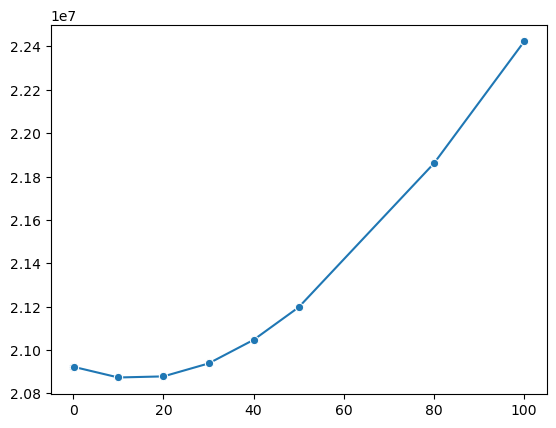

In [22]:
alphas = [0.001,0.1,0.002 ,10, 20, 30 , 40 ,50,80, 100 ]
mses = []
for a in alphas:
    lasso_model = Lasso(alpha= a)
    lasso_model.fit(x_train,y_train)
    
    y_pred  = lasso_model.predict(x_test)
    mse = mean_squared_error(y_test,y_pred)
    print(f"MSE for alpha = {a}:", mse)
    mses.append(mse)

sns.lineplot(x= alphas, y = mses, marker= "o")

In [25]:
from sklearn.linear_model import LassoCV
a = [0.001,0.1,0.002 ,10, 20, 30 , 40 ,50,80, 100 ]
mses = []

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter= 1000,
    random_state = 42
)

lasso_cv_model.fit(x_train,y_train)
y_pred = lasso_cv_model.predict(x_test)
mse = mean_squared_error(y_test,y_pred)
print("best alpha: ", lasso_cv_model.alpha_)
print("MSE :", mse)

best alpha:  0.001
MSE : 20922599.87103596
